# BNP Paribas.

# Bussines Case Project 2025/2026

Group:V
   - Alano Gonçalves (20250457)
   - Catarina ()
   - João Carichas (20250507)
   - Marta Ribeiro ()
   - Nicole Nogeira()

# Index

- [1. Import](#import)
  - [1.1 Import libraries](#import-libraries)
  - [1.2 Import the dataset](#import-the-dataset)
- [2. Data Exploration](#data-Exploration)
  - [2.1 MetaData](#metadata)
  - [2.2 Analysing the Data](#Analysing-the-Data)
  - [2.3 Data Visualization](#Data-visualization)
  - [2.4 Correlation Check](#correlation-check)
- [3. Data Quality & Feature Engineering](#Data-Quality-&-Feature-Engineering)
  - [3.1 Data Quality](#Data-Quality)
  - [3.2 Feature Engineering](#Feature-Engineering)
- [4. Implications for Clustering](#Implications-for-Clustering)
  

<div class="alert alert-block alert-info">

<a class="anchor" id="1. Import">    </a>
# 1. Import
       
</div>


[Back to Index](#index)

<a class="anchor" id="1.1 Import Libraries">

## 1.1 Import Libraries
    
</a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil

<a class="anchor" id="1.2 Import the Dataset">

## 1.2 Import the Dataset
    
</a>

In [2]:
#!pip install pandas pyarrow
#!pip install fastparquet

In [3]:
file_path_CRC = r"C:/Users/jcari/OneDrive/Ambiente de Trabalho/NOVA IMS/Business Cases/Case 1/crc.parquet"
file_path_CREDSCORE = r"C:/Users/jcari/OneDrive/Ambiente de Trabalho/NOVA IMS/Business Cases/Case 1/BNP-Paribas-main/BNP-Paribas/credscore.parquet"
file_path_BDOSS = r"C:/Users/jcari/OneDrive/Ambiente de Trabalho/NOVA IMS/Business Cases/Case 1/bdoss.parquet"
file_path_FAMA = r"C:/Users/jcari/OneDrive/Ambiente de Trabalho/NOVA IMS/Business Cases/Case 1/BNP-Paribas-main/BNP-Paribas/fama.parquet"

# Ler o ficheiro parquet
CRC = pd.read_parquet(file_path_CRC, engine="fastparquet")
CREDSCORE = pd.read_parquet(file_path_CREDSCORE, engine="fastparquet")
FAMA = pd.read_parquet(file_path_FAMA, engine="fastparquet")
BDOSS = pd.read_parquet(file_path_BDOSS, engine="fastparquet")

<div class="alert alert-block alert-info">

<a class="anchor" id="2. Data Exploration">    </a>
# 2. Data Exploration
       
</div>


[Back to Index](#index)

<a class="anchor" id="2.1 MetaData">

## 2.1 MetaData

<a class="anchor" id="2.2 Analysing the Data">

## 2.2 Analysing the Data
    
</a>

<a class="anchor" id="2.2.1 CRC">

## 2.2.1 CRC
    
</a>

In [4]:
CRC.head()

,CONTRIB,OBS_DATE,MT_MENSAL,COUNT_CL,COUNT_CP,COUNT_AUTO,COUNT_HT,COUNT_CONEXO,COUNT_OTHER,COUNT_TOTAL,...,MONTVENC_AUTO,MONTVENC_HT,MONTABATV_CL,MONTABATV_CP,MONTABATV_AUTO,MONTABATV_HT,DIVIDAS_CL,DIVIDAS_CP,DIVIDAS_AUTO,DIVIDAS_HT
0,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,2023-12-31,NaN,1.0,4.0,0.0,0.0,0.0,1.0,6.0,...,0.0,0.0,0.0,0.0,0.0,0.0,6842.10,963.55,0.00,0.00
1,0000ab2116257783438c70ff85a3e98f2d4194ebe53434...,2023-12-31,547.18,4.0,5.0,0.0,0.0,0.0,1.0,10.0,...,0.0,0.0,0.0,0.0,0.0,0.0,28532.06,7115.46,0.00,0.00
2,0000f858346061c53064586a3347b34659565a6712d004...,2023-12-31,NaN,1.0,5.0,1.0,1.0,0.0,0.0,8.0,...,0.0,0.0,0.0,0.0,0.0,0.0,2957.28,2150.90,2408.56,85549.49
3,00025459b703e1c308553e83a6d545a71fe6a787c2dd1c...,2023-12-31,515.57,3.0,1.0,0.0,0.0,0.0,1.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,27120.42,152.95,0.00,0.00
4,00041ebafb1270a818c30cb1fb20d3699002196644ea8f...,2023-12-31,NaN,8.0,3.0,0.0,0.0,0.0,1.0,12.0,...,0.0,0.0,0.0,0.0,0.0,0.0,46104.39,4128.54,0.00,0.00


In [5]:
CRC.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3034921 entries, 0 to 3034920
Data columns (total 22 columns):
 #   Column          Dtype         
---  ------          -----         
 0   CONTRIB         object        
 1   OBS_DATE        datetime64[ns]
 2   MT_MENSAL       float64       
 3   COUNT_CL        float64       
 4   COUNT_CP        float64       
 5   COUNT_AUTO      float64       
 6   COUNT_HT        float64       
 7   COUNT_CONEXO    float64       
 8   COUNT_OTHER     float64       
 9   COUNT_TOTAL     float64       
 10  MONTVENC_CL     float64       
 11  MONTVENC_CP     float64       
 12  MONTVENC_AUTO   float64       
 13  MONTVENC_HT     float64       
 14  MONTABATV_CL    float64       
 15  MONTABATV_CP    float64       
 16  MONTABATV_AUTO  float64       
 17  MONTABATV_HT    float64       
 18  DIVIDAS_CL      float64       
 19  DIVIDAS_CP      float64       
 20  DIVIDAS_AUTO    float64       
 21  DIVIDAS_HT      float64       
dtypes: datetime64[ns](

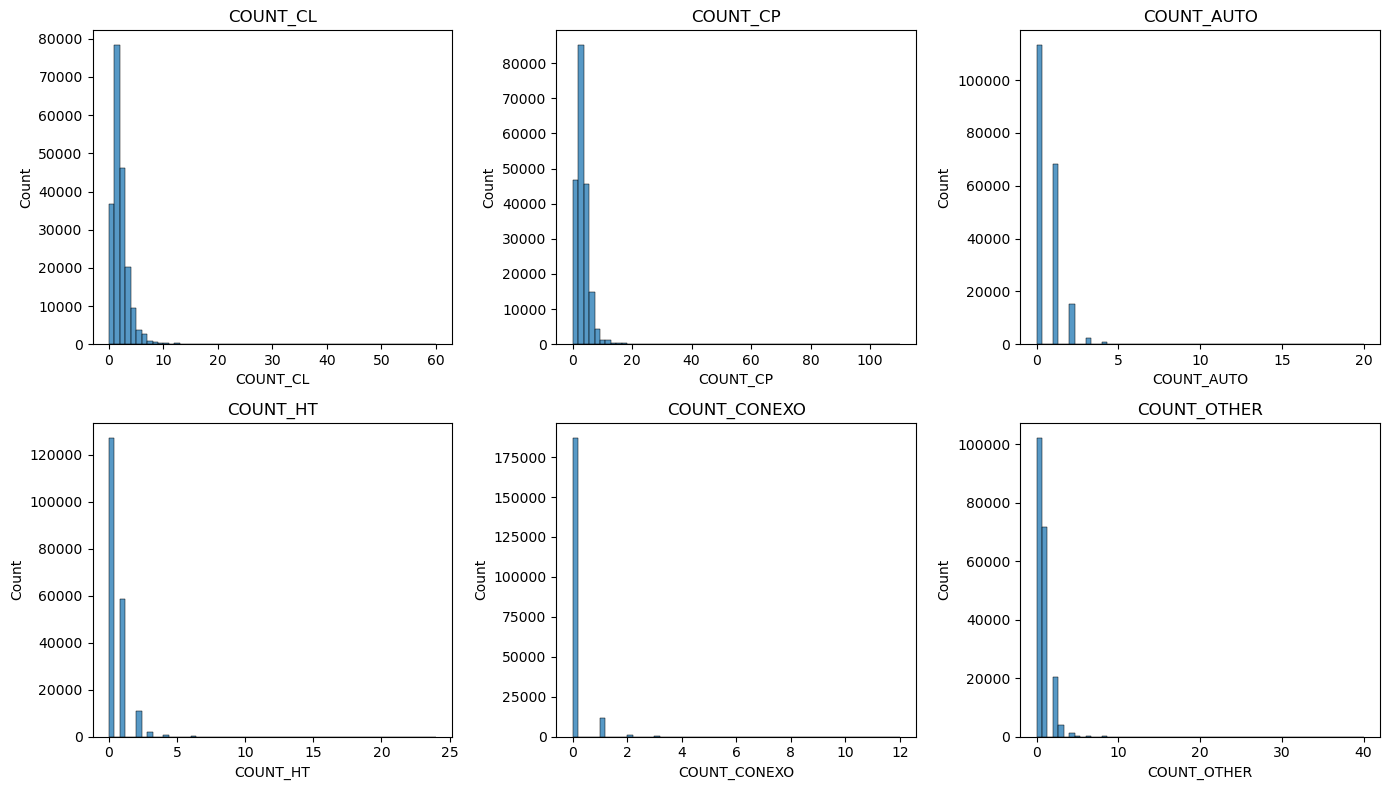

In [6]:
numeric_cols = ['COUNT_CL', 'COUNT_CP', 'COUNT_AUTO', 'COUNT_HT', 'COUNT_CONEXO', 'COUNT_OTHER', 'COUNT_TOTAL', 'MONTVENC_CL', 'MONTVENC_CP', 'MONTVENC_AUTO', 'MONTVENC_HT', 
                'MONTABATV_CL', 'MONTABATV_CP', 'MONTABATV_AUTO', 'MONTABATV_HT', 'DIVIDAS_CL', 'DIVIDAS_CP', 'DIVIDAS_AUTO', 'DIVIDAS_HT']

N = 200_000 
sample = CRC.sample(n=min(N, len(CRC)), random_state=42) 
cols = numeric_cols[:6] 

fig, axes = plt.subplots(2, 3, figsize=(14, 8)) 
axes = axes.ravel() 
for ax, col in zip(axes, cols): 
    sns.histplot(sample[col].dropna(), bins=60, kde=False, ax=ax) 
    ax.set_title(col) 

plt.tight_layout() 
plt.show()

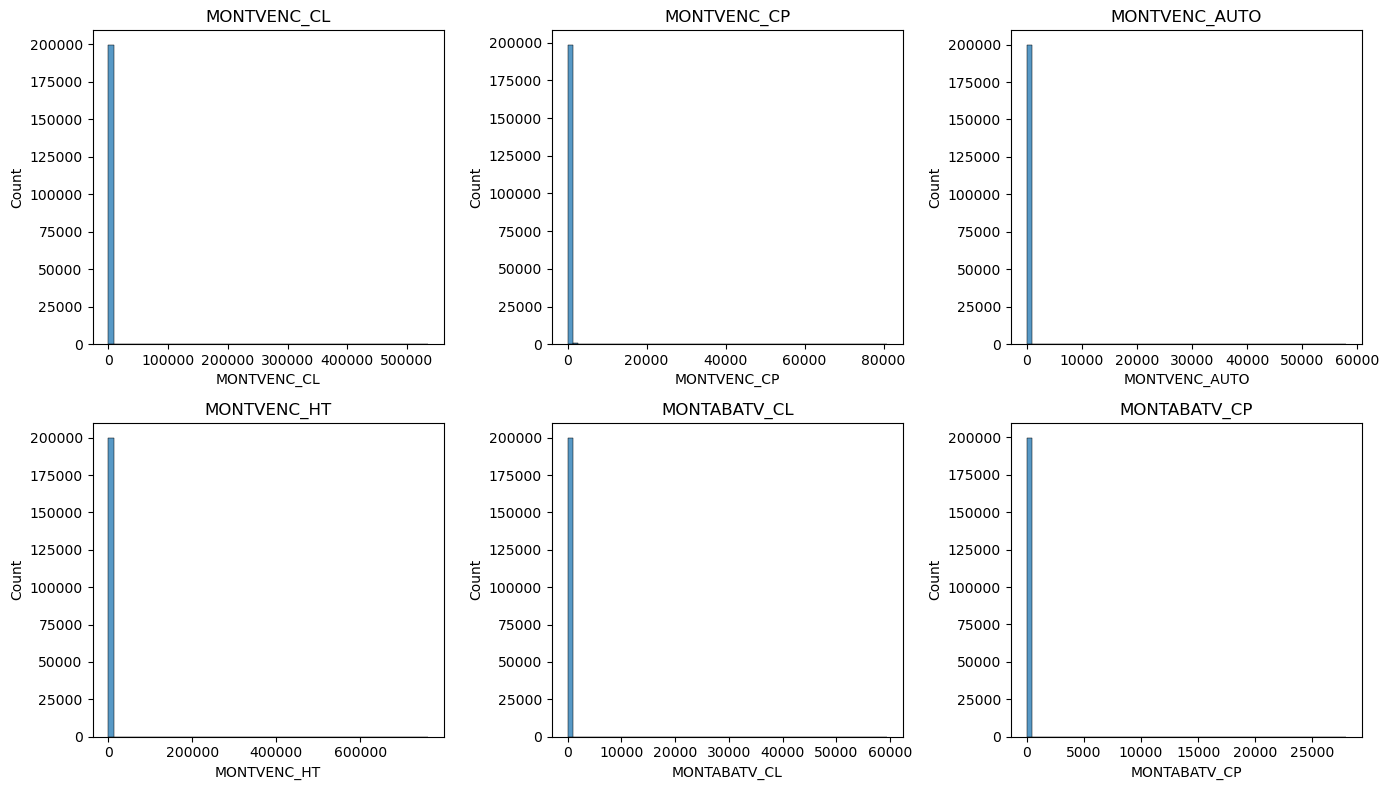

In [7]:
N = 200_000 
sample = CRC.sample(n=min(N, len(CRC)), random_state=42) 
cols = numeric_cols[7:13] 

fig, axes = plt.subplots(2, 3, figsize=(14, 8)) 
axes = axes.ravel() 
for ax, col in zip(axes, cols): 
    sns.histplot(sample[col].dropna(), bins=60, kde=False, ax=ax) 
    ax.set_title(col) 

plt.tight_layout() 
plt.show()

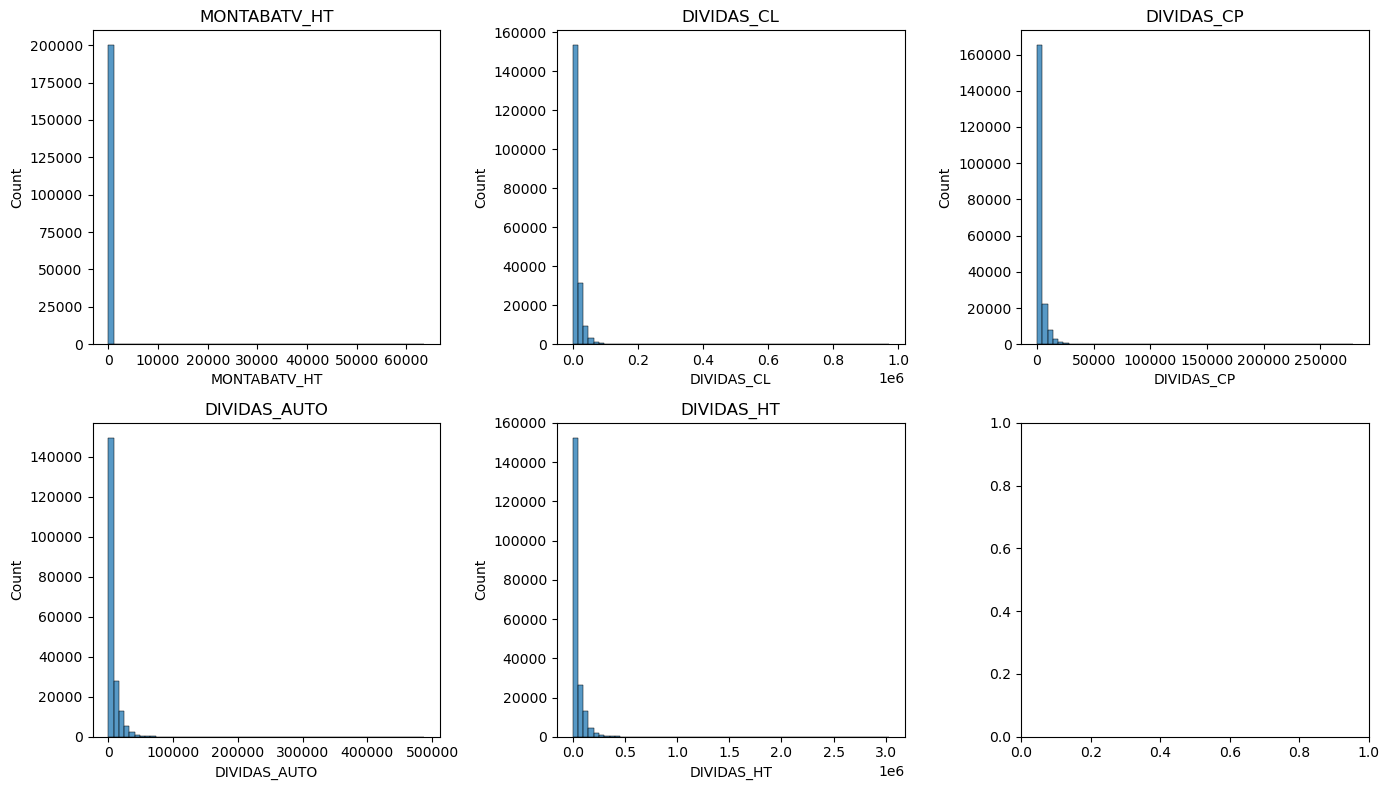

In [8]:
N = 200_000 
sample = CRC.sample(n=min(N, len(CRC)), random_state=42) 
cols = numeric_cols[14:20] 

fig, axes = plt.subplots(2, 3, figsize=(14, 8)) 
axes = axes.ravel() 
for ax, col in zip(axes, cols): 
   sns.histplot(sample[col].dropna(), bins=60, kde=False, ax=ax) 
   ax.set_title(col) 

plt.tight_layout() 
plt.show()

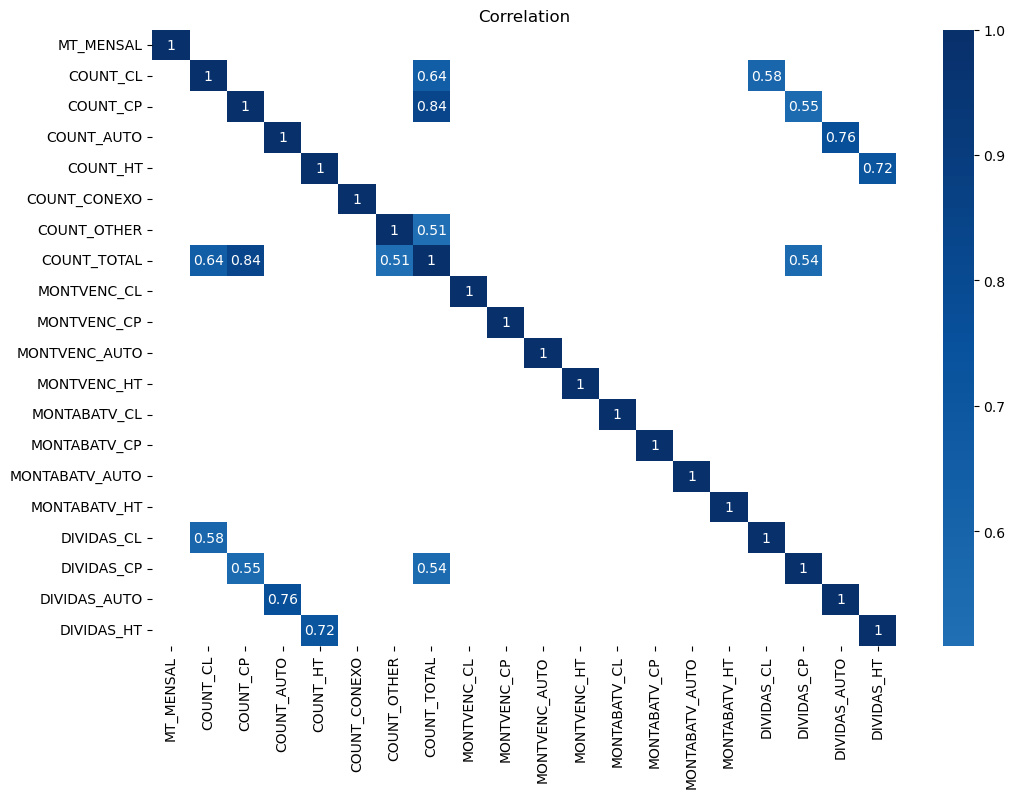

In [9]:
corr = CRC.corr(numeric_only=True)

mask = (corr.abs() < 0.5)

plt.figure(figsize=(12,8))
sns.heatmap(corr, 
            mask=mask, 
            annot=True, 
            cmap="Blues", 
            center=0)

plt.title("Correlation")
plt.show()

<a class="anchor" id="2.2.2 CREDSCORE">

## 2.2.2 CREDSCORE
    
</a>

In [10]:
CREDSCORE.head()

,CONTRIB,sys_numero_submissao,sys_data_procura,kp_sqe,ks_score_tier
0,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,22.0,2025-02-05,H,2.0
1,0000ab2116257783438c70ff85a3e98f2d4194ebe53434...,4.0,2025-04-09,D,1.0
2,00041ebafb1270a818c30cb1fb20d3699002196644ea8f...,1.0,2023-08-08,F,3.0
3,00050fe9f0e69ce221a574af0baaff0b37c598af7a5cc6...,4.0,2023-09-11,A,1.0
4,0005f134494d2ab97ed5d4164994dcde766a3f77cdb3a9...,15.0,2025-08-14,H,1.0


In [11]:
CREDSCORE.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63704 entries, 0 to 63703
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   CONTRIB               63704 non-null  object        
 1   sys_numero_submissao  63704 non-null  float64       
 2   sys_data_procura      63704 non-null  datetime64[ns]
 3   kp_sqe                45653 non-null  object        
 4   ks_score_tier         63704 non-null  float64       
dtypes: datetime64[ns](1), float64(2), object(2)
memory usage: 2.4+ MB


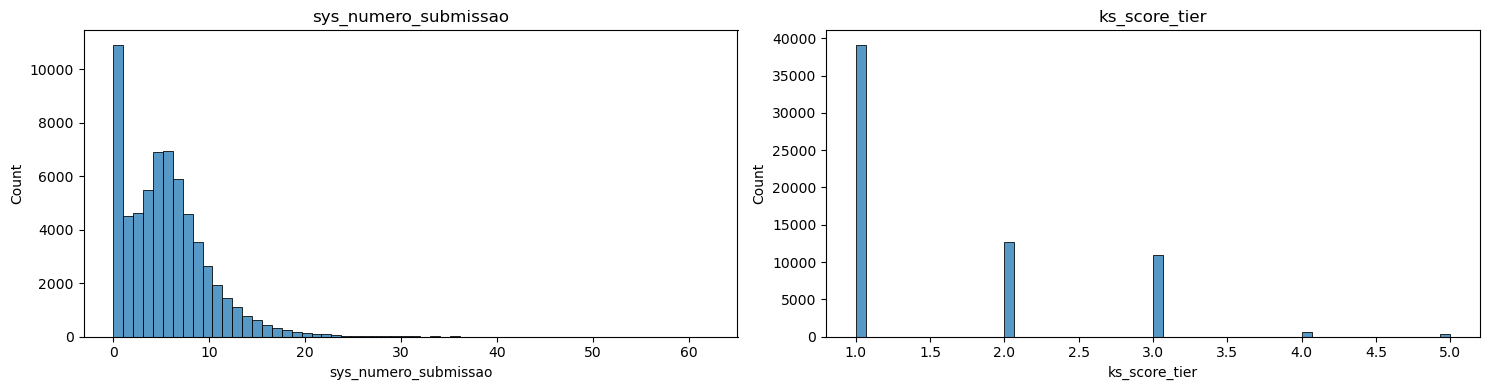

In [12]:
numeric_cols_1 = ["sys_numero_submissao","ks_score_tier"]

fig, axes = plt.subplots(1, len(numeric_cols_1), figsize=(15, 4))
axes = axes.ravel()

for ax, col in zip(axes, numeric_cols_1):
    sns.histplot(CREDSCORE[col].dropna(), bins=60, kde=False, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

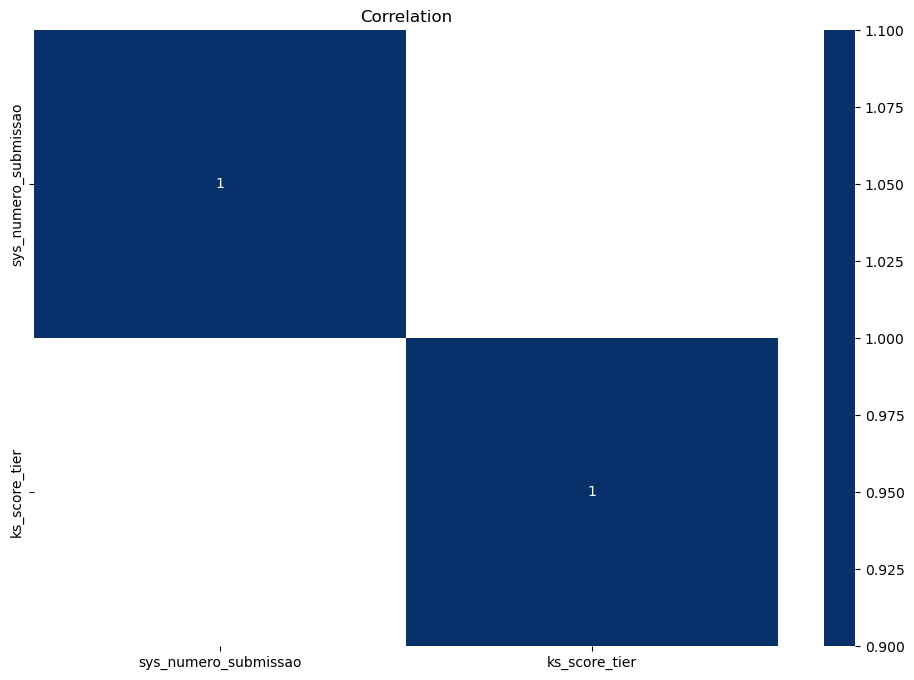

In [13]:
corr = CREDSCORE.corr(numeric_only=True)

mask = (corr.abs() < 0.5)

plt.figure(figsize=(12,8))
sns.heatmap(corr, 
            mask=mask, 
            annot=True, 
            cmap="Blues", 
            center=0)

plt.title("Correlation")
plt.show()

<a class="anchor" id="2.2.3 FAMA">

## 2.2.3 FAMA
    
</a>

In [14]:
FAMA.head()

,CONTRIB,Date_Obs,ALLBD_N_Dossiers__N,ALLBD_N_CL__N,ALLBD_N_CP__N,ALLBD_A_CL__N,ALLBD_A_CP__N,ALLBD_MTFINO_CL__N,ALLBD_MTFINO_CP__N,ALLBD_MTFIN_CL__N,...,ALLBD_IDADE_MEAN__N,ALLBD_SUM_NUMFIN_CP__N,ALLBD_mean_active_resso__N,ALLBD_max_active_resso__N,ALLBD_mean_duration_CL__N,ALLBD_mean_lifecycle_CL__N,ALLBD_N_events__N,sdem_SITFAM,sdem_HABITAT,sdem_age
0,31f4b2a40e2cc73faf9cf16c7bd6ebeea6f322931d4e0b...,2024-11-30,15.0,6.0,9.0,1.0,0.0,88784.04,0.00,88784.040000,...,1280.533333,0.0,1153.000000,1153.0,120.0,0.425000,15.0,C,P,62
1,bb7bc8dfa33e27eb832f58210a2d3282839cd2a8e7f420...,2024-11-30,6.0,4.0,2.0,1.0,2.0,9584.91,7628.41,9584.910000,...,466.333333,14.0,1564.666667,1582.0,72.0,0.138889,6.0,C,A,65
2,a377de96fc89a1aabdb5e25682e54c7d02a7209c7246d0...,2024-11-30,8.0,5.0,3.0,1.0,0.0,22000.86,0.00,22000.860000,...,907.625000,0.0,1765.000000,1765.0,36.0,0.277778,8.0,C,L,65
3,9e4d032b84105ac4981257fc993ed33f60dfec1542c723...,2024-11-30,3.0,3.0,0.0,1.0,0.0,10384.00,0.00,10384.000000,...,301.000000,0.0,840.000000,840.0,72.0,0.138889,3.0,V,P,69
4,7d0cb0079863cbf9d6d179491aab944c9af7e988d1e4bc...,2024-11-30,9.0,8.0,1.0,1.0,0.0,12866.23,0.00,13756.584246,...,2267.555556,0.0,3268.000000,3268.0,48.0,0.916667,9.0,C,A,68


In [15]:
FAMA.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 141115 entries, 0 to 141114
Data columns (total 23 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   CONTRIB                     141115 non-null  object        
 1   Date_Obs                    141115 non-null  datetime64[ms]
 2   ALLBD_N_Dossiers__N         141115 non-null  float64       
 3   ALLBD_N_CL__N               141115 non-null  float64       
 4   ALLBD_N_CP__N               141115 non-null  float64       
 5   ALLBD_A_CL__N               141115 non-null  float64       
 6   ALLBD_A_CP__N               141115 non-null  float64       
 7   ALLBD_MTFINO_CL__N          141115 non-null  float64       
 8   ALLBD_MTFINO_CP__N          141115 non-null  float64       
 9   ALLBD_MTFIN_CL__N           141115 non-null  float64       
 10  ALLBD_MTFIN_CP__N           141115 non-null  float64       
 11  ALLBD_IDADE_MSA__N          141115 non-

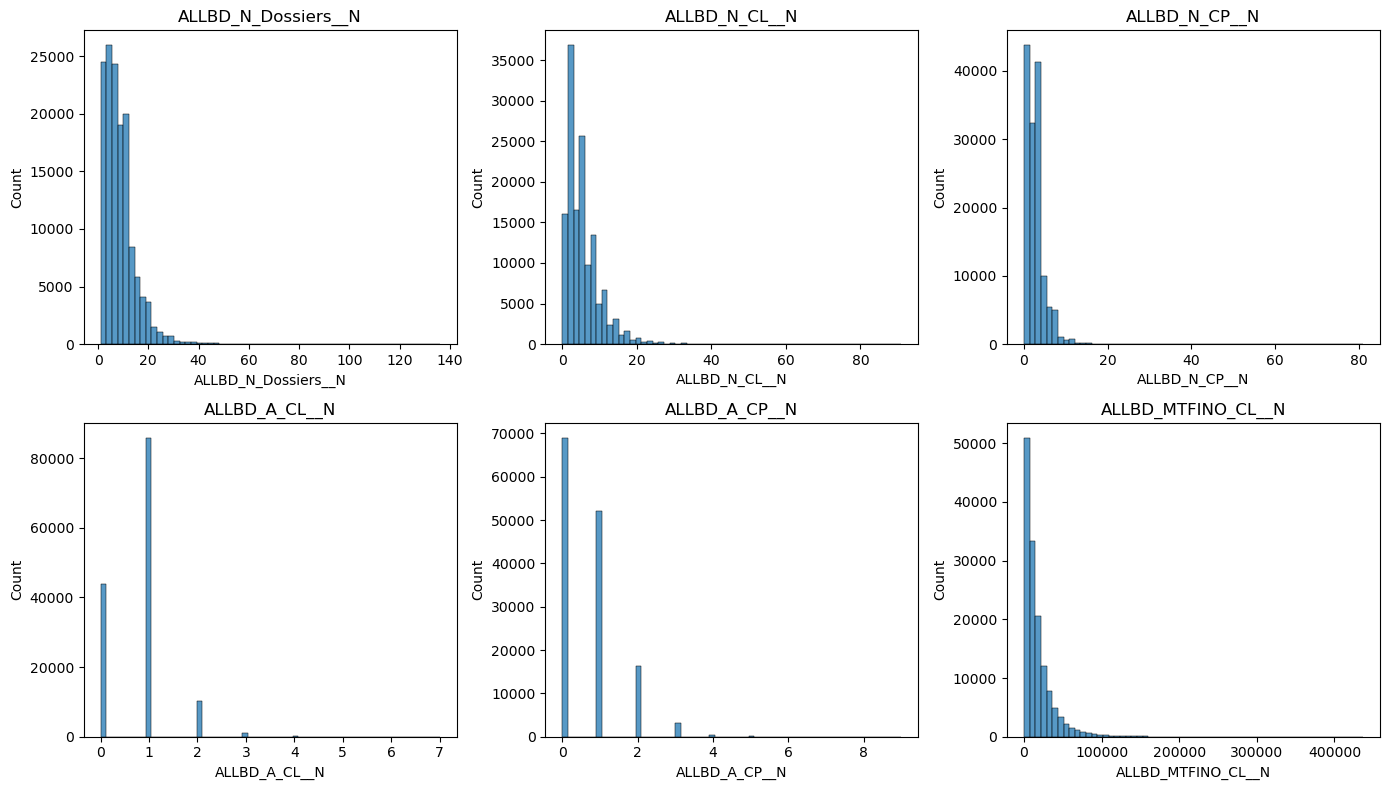

In [16]:
numeric_cols_2 = ['ALLBD_N_Dossiers__N', 'ALLBD_N_CL__N', 'ALLBD_N_CP__N',
                  'ALLBD_A_CL__N', 'ALLBD_A_CP__N', 'ALLBD_MTFINO_CL__N',
                  'ALLBD_MTFINO_CP__N', 'ALLBD_MTFIN_CL__N', 'ALLBD_MTFIN_CP__N',
                  'ALLBD_IDADE_MSA__N', 'ALLBD_IDADE_MIN__N', 'ALLBD_IDADE_MEAN__N',
                  'ALLBD_SUM_NUMFIN_CP__N', 'ALLBD_mean_active_resso__N',
                  'ALLBD_max_active_resso__N', 'ALLBD_mean_duration_CL__N',
                  'ALLBD_mean_lifecycle_CL__N', 'ALLBD_N_events__N',
                  'sdem_SITFAM', 'sdem_HABITAT', 'sdem_age']

cols = numeric_cols_2[:6]  # apenas 6

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

for ax, col in zip(axes, cols):
    sns.histplot(FAMA[col].dropna(), bins=60, kde=False, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

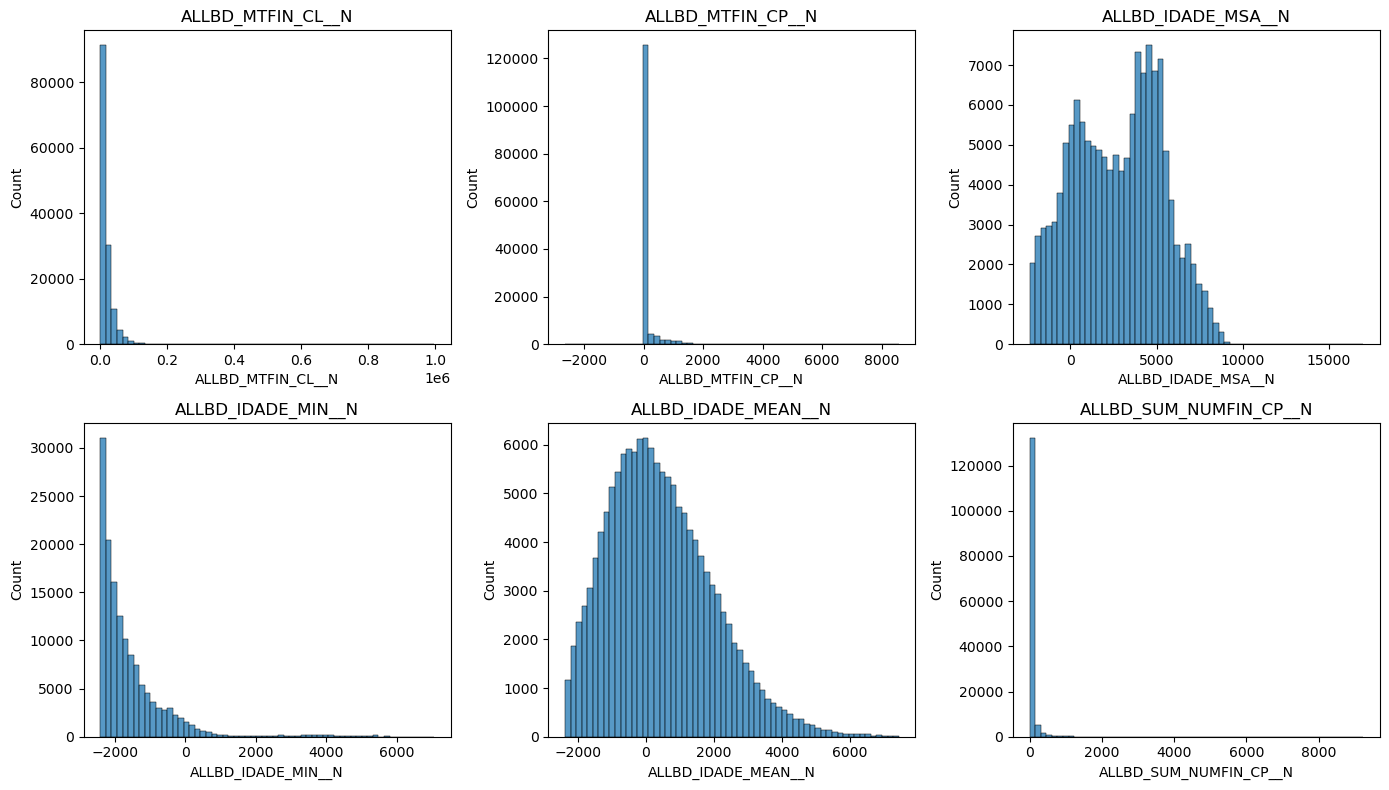

In [17]:
cols = numeric_cols_2[7:13]  # apenas 6

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

for ax, col in zip(axes, cols):
    sns.histplot(FAMA[col].dropna(), bins=60, kde=False, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

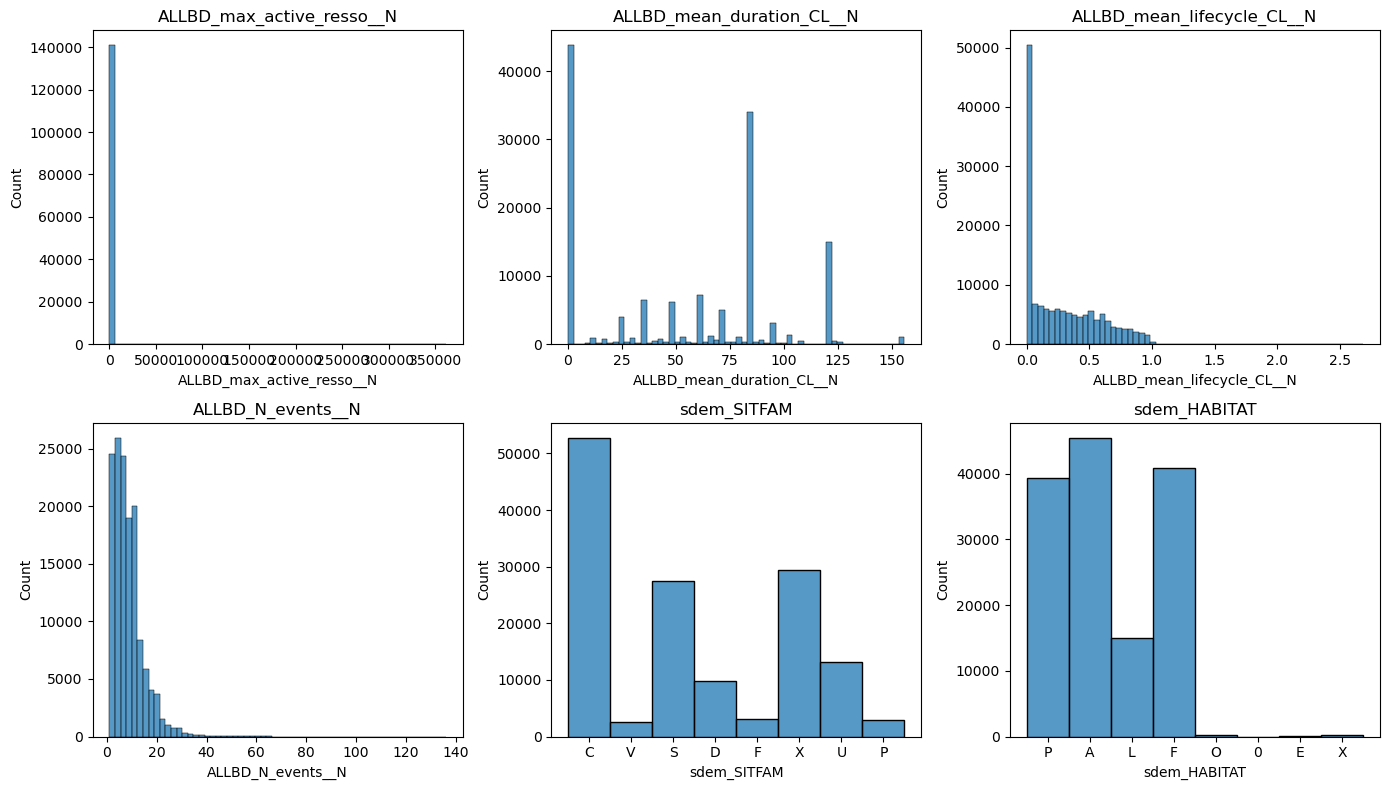

In [18]:
cols = numeric_cols_2[14:20]  # apenas 6

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

for ax, col in zip(axes, cols):
    sns.histplot(FAMA[col].dropna(), bins=60, kde=False, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

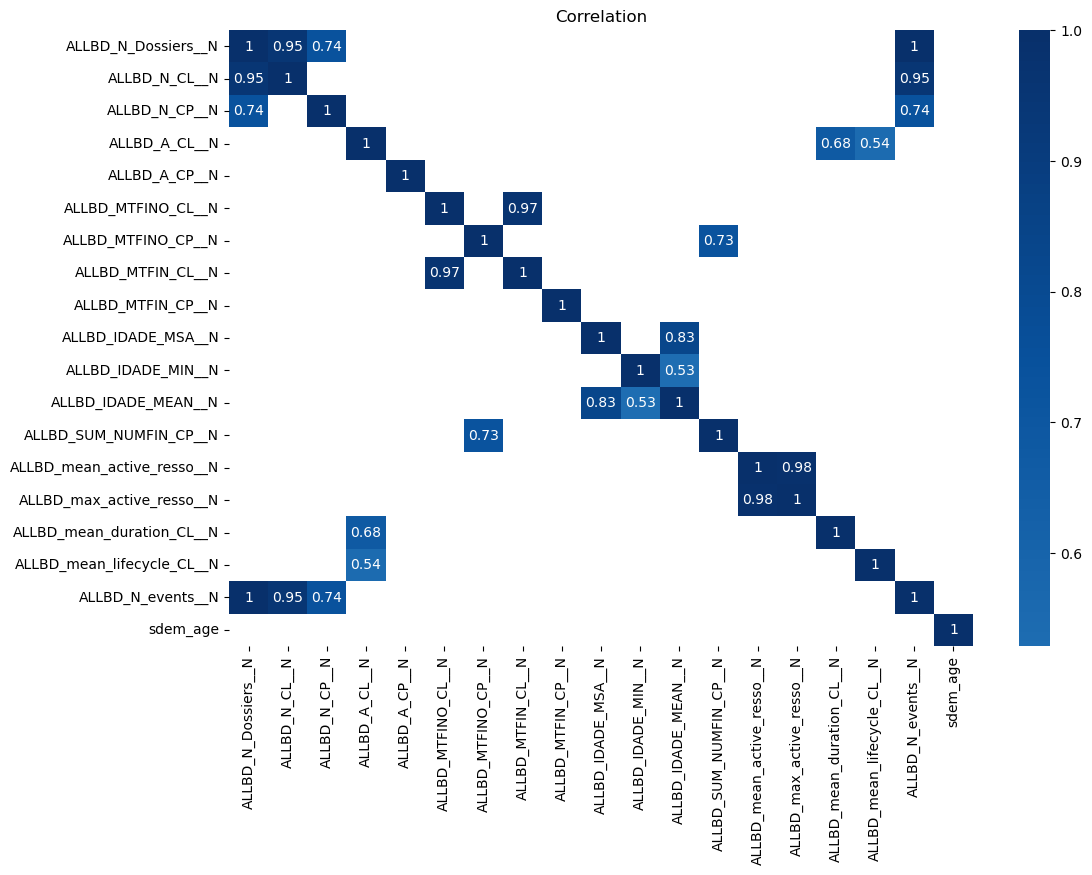

In [19]:
corr = FAMA.corr(numeric_only=True)

mask = (corr.abs() < 0.5)

plt.figure(figsize=(12,8))
sns.heatmap(corr, 
            mask=mask, 
            annot=True, 
            cmap="Blues", 
            center=0)

plt.title("Correlation")
plt.show()

<a class="anchor" id="2.2.4 BDOSS">

## 2.2.4 BDOSS
    
</a>

In [20]:
pd.set_option('display.max_columns', None)
BDOSS.head()

,CONTRIB,DOSSIER,POLE,TYPEPROD,PRODALP,BICONTRATO,POS,OBS_DATE,DCREAT,DATFIN,D1FIN,DPOS,DURDEG,RANGPRO,RANGCLI,MTFINO,MTFIN,MENSALIDADE,MENSALIDADE_CORR,CRD,SREC,ACTIVIDADE_GLOBAL,RN,RD,RISK,RISKA,AGFIN,PAGAMENTO,RESSO,CSP,DCSP,NATIO,PTT,NBENF,MODCONTACTO
0,0000ab2116257783438c70ff85a3e98f2d4194ebe53434...,9e4d186f6f66f2da4b816cbc6f6e05e640caf5ded07956...,P,CL,EP,0.0,ENC,2024-01-31,2018-03-29,2018-04-16,2018-04-16,2018-04-16,120.0,69.0,69.0,20000.0,20000.0,347.447280,NaN,13208.455,0.000,NaN,0.0,0.0,000000000000000000000000,0.0,120.0,P,1113.258,80.0,1988.0,P,2845,1.0,A
1,0000e359b15a80ba12c7f60c0fe06ffc68621c87f13a4f...,b83e6ef0c9c12f8304d86c40458a5b88ec72e534201c32...,P,CL,EP,0.0,SAN,2024-01-31,2019-01-28,2019-02-04,2019-02-04,2022-12-28,72.0,34.0,34.0,2500.0,2500.0,56.017772,NaN,0.000,0.000,NaN,1.0,1.0,000000000000210210000110,0.0,120.0,N,838.186,91.0,1990.0,P,2855,0.0,A
2,0000f858346061c53064586a3347b34659565a6712d004...,29c3cfb34c4e2ecd6749b0c1a6205dfce33c0e71751456...,P,CL,EP,0.0,ENC,2024-01-31,2019-09-23,2019-09-30,2019-09-30,2019-09-30,84.0,52.0,52.0,5000.0,5000.0,100.073575,NaN,2665.191,0.000,NaN,0.0,0.0,000000000000000000000000,0.0,118.0,P,1314.144,80.0,2013.0,P,2635,2.0,W
3,00025459b703e1c308553e83a6d545a71fe6a787c2dd1c...,446d96905d26356fb4f1d3e1e6da3868b8106b09a558e6...,P,CL,EPF,0.0,ENC,2024-01-31,2023-01-09,2023-01-13,2023-01-13,2023-01-13,60.0,13.0,37.0,6000.0,6000.0,162.097525,NaN,5893.092,0.000,NaN,0.0,0.0,000000000000000000000000,0.0,117.0,P,1031.650,80.0,1989.0,P,5090,0.0,A
4,00041ebafb1270a818c30cb1fb20d3699002196644ea8f...,26d59ea8a93be739e9fc4a0404f07c73aae276243e5cd6...,N,CL,EXT,0.0,ENC,2024-01-31,2021-02-10,2021-02-17,2021-02-17,2024-01-31,84.0,32.0,32.0,20500.0,20500.0,463.755537,NaN,17844.618,-463.756,NaN,2.0,4.0,000000000000000002112122,0.0,119.0,P,1113.258,80.0,2019.0,P,2835,0.0,A


In [21]:
BDOSS.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2658187 entries, 0 to 2658186
Data columns (total 35 columns):
 #   Column             Dtype         
---  ------             -----         
 0   CONTRIB            object        
 1   DOSSIER            object        
 2   POLE               object        
 3   TYPEPROD           object        
 4   PRODALP            object        
 5   BICONTRATO         float64       
 6   POS                object        
 7   OBS_DATE           datetime64[ns]
 8   DCREAT             datetime64[ns]
 9   DATFIN             datetime64[ns]
 10  D1FIN              datetime64[ns]
 11  DPOS               datetime64[ns]
 12  DURDEG             float64       
 13  RANGPRO            float64       
 14  RANGCLI            float64       
 15  MTFINO             float64       
 16  MTFIN              float64       
 17  MENSALIDADE        float64       
 18  MENSALIDADE_CORR   float64       
 19  CRD                float64       
 20  SREC               float

In [148]:
BDOSS['BICONTRATO'] = BDOSS['BICONTRATO'].round().astype('Int32')
BDOSS['DURDEG'] = BDOSS['DURDEG'].round().astype('Int32')
BDOSS['RANGPRO'] = BDOSS['RANGPRO'].round().astype('Int32')
BDOSS['RANGCLI'] = BDOSS['RANGCLI'].round().astype('Int32')

In [22]:
BDOSS.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
CONTRIB,2658187,148729,364aad4f1733591b129753f295cca317a449f207c209bd...,158,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DOSSIER,2658187,185592,f8908577ee5bab0f764f1f007f439370b0511585b89d96...,46,NaN,NaN,NaN,NaN,NaN,NaN,NaN
POLE,2658187,2,P,2615205,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TYPEPROD,2658187,1,CL,2658187,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PRODALP,2658187,4,EP,1912612,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BICONTRATO,2658187.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
POS,2658187,4,ENC,2214397,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OBS_DATE,2658187,NaN,NaN,NaN,2024-12-31 12:04:59.079635456,2024-01-31 00:00:00,2024-06-30 00:00:00,2024-12-31 00:00:00,2025-06-30 00:00:00,2025-11-30 00:00:00,NaN
DCREAT,2658187,NaN,NaN,NaN,2022-03-23 09:42:27.446511104,1996-06-14 00:00:00,2020-11-24 00:00:00,2022-10-20 00:00:00,2024-01-31 00:00:00,2025-12-02 00:00:00,NaN
DATFIN,2658187,NaN,NaN,NaN,2022-04-01 11:27:02.187001088,1996-06-17 00:00:00,2020-12-02 00:00:00,2022-10-28 00:00:00,2024-02-07 00:00:00,2025-12-02 00:00:00,NaN


## **Documentação:**

**- Duplicates**

In [149]:
BDOSS.duplicated().sum()

np.int64(0)

**- Missing Values**

In [23]:
BDOSS.isna().sum()[BDOSS.isna().sum() > 0]

RANGCLI                    1
MENSALIDADE_CORR     2658187
ACTIVIDADE_GLOBAL    2658187
DCSP                  293663
NATIO                      1
NBENF                    736
MODCONTACTO            59544
dtype: int64

In [41]:
#checking umber of missing values in each column as a percentage
BDOSS.isna().sum()[BDOSS.isna().sum() > 0]/len(BDOSS) * 100

RANGCLI                0.000038
MENSALIDADE_CORR     100.000000
ACTIVIDADE_GLOBAL    100.000000
DCSP                  11.047492
NATIO                  0.000038
NBENF                  0.027688
MODCONTACTO            2.240023
dtype: float64

**- Constant Features**

In [24]:
BDOSS['MENSALIDADE_CORR'].unique()

array([nan])

In [25]:
BDOSS['ACTIVIDADE_GLOBAL'].unique()

array([nan])

In [31]:
BDOSS['TYPEPROD'].unique()

array(['CL'], dtype=object)

In [26]:
BDOSS['BICONTRATO'].unique()

array([0.])

**- RISK and RISKA:**

In [27]:
BDOSS['RISK'].value_counts()

RISK
000000000000000000000000    2327930
444444444444444444444444      23863
000000000000000000000001      16652
000000000000000000000010       7487
000000000000000000000100       6278
                             ...   
010000100001000111122010          1
000000100000000010101010          1
012222222122221221111221          1
000001122222221221122100          1
000110210110000000211221          1
Name: count, Length: 77475, dtype: int64

In [28]:
BDOSS['RISKA'].value_counts()

RISKA
0.0    2571156
1.0      79077
7.0       7954
Name: count, dtype: int64

In [43]:
BDOSS['NBENF'].value_counts() #valores outliers

NBENF
0.0     1538648
1.0      664154
2.0      385790
3.0       59785
4.0        7713
5.0        1288
8.0          23
7.0          23
10.0         11
52.0          8
6.0           6
90.0          2
Name: count, dtype: int64

In [44]:
BDOSS['AGFIN'].value_counts()

AGFIN
118.0    1229325
117.0     720161
120.0     518201
119.0     146805
525.0      39560
112.0       3963
111.0         66
500.0         48
503.0         46
116.0          6
100.0          6
Name: count, dtype: int64

posiçoes relativas a churn:

In [30]:
BDOSS['POS'].unique()

array(['ENC', 'SAN', 'SOL', 'RBT'], dtype=object)

In [42]:
BDOSS['POS'].value_counts()

POS
ENC    2214397
SAN     275931
SOL     152934
RBT      14925
Name: count, dtype: int64

apenas queremos P?

In [32]:
BDOSS['POLE'].value_counts()

POLE
P    2615205
N      42982
Name: count, dtype: int64

nenhum deles aparece no metadata:

In [33]:
BDOSS['PRODALP'].unique()

array(['EP', 'EPF', 'EXT', 'DEF'], dtype=object)

In [49]:
BDOSS['CSP'].unique()#54, 58, 50, 56, 55, 57, 52, 53, 0 e 51 nao aparecem no metadata

array([80., 91., 35., 60., 90., 54., 70., 31., 74., 20., 58., 15., 41.,
       10., 50., 33., 56., 55., 86., 32., 30., 92., 57., 52., 53., 34.,
       40., 81., 99.,  0., 96., 25., 51.])

In [113]:
BDOSS.columns

Index(['CONTRIB', 'DOSSIER', 'POLE', 'TYPEPROD', 'PRODALP', 'BICONTRATO',
       'POS', 'OBS_DATE', 'DCREAT', 'DATFIN', 'D1FIN', 'DPOS', 'DURDEG',
       'RANGPRO', 'RANGCLI', 'MTFINO', 'MTFIN', 'MENSALIDADE',
       'MENSALIDADE_CORR', 'CRD', 'SREC', 'ACTIVIDADE_GLOBAL', 'RN', 'RD',
       'RISK', 'RISKA', 'AGFIN', 'PAGAMENTO', 'RESSO', 'CSP', 'DCSP', 'NATIO',
       'PTT', 'NBENF', 'MODCONTACTO'],
      dtype='object')

**mudar estas 253 linhas para que RANGPRO == DURDEG**

In [ ]:
BDOSS[BDOSS['RANGPRO'] - BDOSS['DURDEG'] > 0]

,CONTRIB,DOSSIER,POLE,TYPEPROD,PRODALP,BICONTRATO,POS,OBS_DATE,DCREAT,DATFIN,D1FIN,DPOS,DURDEG,RANGPRO,RANGCLI,MTFINO,MTFIN,MENSALIDADE,MENSALIDADE_CORR,CRD,SREC,ACTIVIDADE_GLOBAL,RN,RD,RISK,RISKA,AGFIN,PAGAMENTO,RESSO,CSP,DCSP,NATIO,PTT,NBENF,MODCONTACTO,HISTORIAL


In [153]:
mask = (BDOSS['RANGPRO'] == BDOSS['DURDEG'] + 1)  #os tais 253 casos
BDOSS.loc[mask, 'RANGPRO'] = BDOSS.loc[mask, 'DURDEG']
#BDOSS.loc[mask, 'DURDEG'] = BDOSS.loc[mask, 'RANGPRO'] caso seja ao contrario

## **Feature Engineering para agregado**

**- média do historial dos 24 meses**

In [150]:
BDOSS['HISTORIAL'] = (BDOSS['RISK'].astype(str).apply(lambda x: sum(int(i) for i in x) / len(x)))

In [151]:
BDOSS

,CONTRIB,DOSSIER,POLE,TYPEPROD,PRODALP,BICONTRATO,POS,OBS_DATE,DCREAT,DATFIN,D1FIN,DPOS,DURDEG,RANGPRO,RANGCLI,MTFINO,MTFIN,MENSALIDADE,MENSALIDADE_CORR,CRD,SREC,ACTIVIDADE_GLOBAL,RN,RD,RISK,RISKA,AGFIN,PAGAMENTO,RESSO,CSP,DCSP,NATIO,PTT,NBENF,MODCONTACTO,HISTORIAL
0,0000ab2116257783438c70ff85a3e98f2d4194ebe53434...,9e4d186f6f66f2da4b816cbc6f6e05e640caf5ded07956...,P,CL,EP,0,ENC,2024-01-31,2018-03-29,2018-04-16,2018-04-16,2018-04-16,120,69,69,20000.0,20000.0,347.447280,NaN,13208.455,0.000,NaN,0.0,0.0,000000000000000000000000,0.0,120.0,P,1113.258,80.0,1988.0,P,2845,1.0,A,0.000000
1,0000e359b15a80ba12c7f60c0fe06ffc68621c87f13a4f...,b83e6ef0c9c12f8304d86c40458a5b88ec72e534201c32...,P,CL,EP,0,SAN,2024-01-31,2019-01-28,2019-02-04,2019-02-04,2022-12-28,72,34,34,2500.0,2500.0,56.017772,NaN,0.000,0.000,NaN,1.0,1.0,000000000000210210000110,0.0,120.0,N,838.186,91.0,1990.0,P,2855,0.0,A,0.333333
2,0000f858346061c53064586a3347b34659565a6712d004...,29c3cfb34c4e2ecd6749b0c1a6205dfce33c0e71751456...,P,CL,EP,0,ENC,2024-01-31,2019-09-23,2019-09-30,2019-09-30,2019-09-30,84,52,52,5000.0,5000.0,100.073575,NaN,2665.191,0.000,NaN,0.0,0.0,000000000000000000000000,0.0,118.0,P,1314.144,80.0,2013.0,P,2635,2.0,W,0.000000
3,00025459b703e1c308553e83a6d545a71fe6a787c2dd1c...,446d96905d26356fb4f1d3e1e6da3868b8106b09a558e6...,P,CL,EPF,0,ENC,2024-01-31,2023-01-09,2023-01-13,2023-01-13,2023-01-13,60,13,37,6000.0,6000.0,162.097525,NaN,5893.092,0.000,NaN,0.0,0.0,000000000000000000000000,0.0,117.0,P,1031.650,80.0,1989.0,P,5090,0.0,A,0.000000
4,00041ebafb1270a818c30cb1fb20d3699002196644ea8f...,26d59ea8a93be739e9fc4a0404f07c73aae276243e5cd6...,N,CL,EXT,0,ENC,2024-01-31,2021-02-10,2021-02-17,2021-02-17,2024-01-31,84,32,32,20500.0,20500.0,463.755537,NaN,17844.618,-463.756,NaN,2.0,4.0,000000000000000002112122,0.0,119.0,P,1113.258,80.0,2019.0,P,2835,0.0,A,0.458333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2658182,fffb0b5e039cf837e38c5abe51fb5d9db7366c12609d56...,742f4161a1912448fa135ea77f855781eab6176dd9e75b...,P,CL,EP,0,ENC,2025-11-30,2020-12-27,2020-12-30,2020-12-30,2020-12-30,120,59,59,12500.0,12500.0,216.051740,NaN,9474.858,0.000,NaN,0.0,0.0,000000000000000000000000,0.0,120.0,P,957.059,60.0,2017.0,P,2840,0.0,W,0.000000
2658183,fffbc66ca4256976c9932916770f1ff3b23aacce5998ff...,dea39098d015a030ea0b3ead87c82ccca9137f784f86c7...,P,CL,EPF,0,ENC,2025-11-30,2018-12-21,2018-12-24,2018-12-24,2025-11-28,84,83,83,7430.0,7430.0,157.667572,NaN,137.403,-157.668,NaN,1.0,2.0,000000000000002001111112,0.0,118.0,P,977.381,31.0,2018.0,P,4820,1.0,W,0.416667
2658184,fffbfb06fdb05fb48a739b0a23650122a66ff61669a5b3...,ac0c808a63bb91659f6f5af780a60c1de56b705618be2a...,P,CL,EP,0,ENC,2025-11-30,2025-03-03,2025-03-04,2025-03-04,2025-03-04,120,9,49,15000.0,15000.0,251.897648,NaN,17422.059,0.000,NaN,0.0,0.0,000000000000000000000000,0.0,118.0,P,0.000,55.0,NaN,P,2745,0.0,W,0.000000
2658185,fffc47b191b25cbc3dbc9ce436b94e52d2084144ee5bec...,43fefbb99328741294aa67fa5bb29cdaf0acff276e282d...,P,CL,EP,0,ENC,2025-11-30,2025-05-29,2025-06-02,2025-06-02,2025-11-25,36,6,6,2000.0,2000.0,81.856368,NaN,1994.881,13.462,NaN,0.0,0.0,000000000000000000000011,0.0,120.0,P,0.000,80.0,2007.0,P,4485,2.0,W,0.083333


## **agregado de dados e implementação de indice**

In [ ]:
def moda(series):
    m = series.mode()
    return m.iloc[0] if not m.empty else np.nan

In [210]:
agg_dossier = (BDOSS.groupby(['CONTRIB', 'DOSSIER']).agg(
    #counting every 'POS' result
    sol_count = ('POS', lambda x: (x == 'SOL').sum()),
    san_count = ('POS', lambda x: (x == 'SAN').sum()),
    enc_count = ('POS', lambda x: (x == 'ENC').sum()),
    rbt_count = ('POS', lambda x: (x == 'RBT').sum()),
    
    #DURDEG, MTFINO and MENSALIDADE are constant in the dossier
    DURDEG = ('DURDEG', 'first'),
    MTFINO = ('MTFINO', 'first'),
    MENSALIDADE = ('MENSALIDADE', 'first'), 

    #RANGPRO, RANGCLI e HISTORIAL - max
    RANGPRO_max = ('RANGPRO', 'max'),
    RANGCLI_max = ('RANGCLI', 'max'),
    HISTORIAL_max = ('HISTORIAL', 'max'),

    #CRD, RESSO AND NBENF - mean
    CRD_mean = ('CRD', 'mean'),
    RESSO_mean = ('RESSO', 'mean'),
    NBENF_mean = ('NBENF', 'mean'),

    #AGFIN, PAGAMENTO, CSP, NATIO, PTT and MODCONTACTO - mode
    AGFIN = ('AGFIN', moda),
    PAGAMENTO = ('PAGAMENTO', moda),
    CSP = ('CSP', moda),
    NATIO = ('NATIO', moda),
    PTT = ('PTT', moda),
    MODCONTACTO = ('MODCONTACTO', moda),
).reset_index())

In [203]:
agg_dossier['DOSSIER'].value_counts()

DOSSIER
a8248459cf59cc2317d86f6fd30957cfc10c9b0ed652f9fad2a8bf9f125d63db    2
f8908577ee5bab0f764f1f007f439370b0511585b89d96f41bf1a00cffdddea9    2
592cac52e59fb2da9e997a2cd1550ab06a843c41f7f234141d72573baeb2196a    2
e20fa81de6820d6a8f77ae5003c6d28315e6718685335ff99c241052b02c80e8    2
50fbe6c6479962fef8576b412584dc5c5075bb88aabc75ddd0dac8d8a1a0962f    2
                                                                   ..
608dddd54d62ef2e2aa222ecc6f999e4cd2ca99d8bbb90356c86468429fcad44    1
e28b4d61da8ad4d31aa9b86b10f18e678e9866255b4f6c0c83dc7578a3e7dedd    1
12c211540d72d457d7c83ca949e3e1927400ac00bbbcac8b2afd92352800ee2e    1
8f5b8d8e6bc74f03f9ba8aea7a35459aa92f49c75974d63eafb4606d8f4e00a3    1
446d96905d26356fb4f1d3e1e6da3868b8106b09a558e61d70dcb3944412ecac    1
Name: count, Length: 185592, dtype: int64

In [180]:
BDOSS['DOSSIER'].value_counts()

DOSSIER
f8908577ee5bab0f764f1f007f439370b0511585b89d96f41bf1a00cffdddea9    46
50fbe6c6479962fef8576b412584dc5c5075bb88aabc75ddd0dac8d8a1a0962f    36
8a60cbae6c0c2d4d56a44d2900367098b8b9154de7cad6107c0b81306fbabc3c    31
7125b55612d0d86033986ddb4e6fc4460aeff0f2312b895e2c806a496c79d23a    23
9e4d186f6f66f2da4b816cbc6f6e05e640caf5ded07956d5fde4919118d37d43    23
                                                                    ..
8bba835476fd11cb1f1dc780ba7ed528b1812a2335f832325aab9bb71d6cd1d5     1
2482bb40bad5be49427b534baa815b288ba27344ef4490266a28c28809782fae     1
c4c269d55a80e0069cbddfd52eece3a8dc2e02c19498465251c581fcd104e084     1
02691e0978b42d035b4cc249ffbc12debaef92548347fbe02fba5c095c67fc9b     1
090d414618296f6fd58cfcd49d2d3dd0afba8de62a3c168fb817d928c97574e8     1
Name: count, Length: 185592, dtype: int64

lista = []
repetidos = []
for i in agg_dossier['DOSSIER']:
    if i not in lista:
        lista.append(i)
    else:
        repetidos.append(i)

repetidos

**DOSSIERS REPETIDOS:**


['50fbe6c6479962fef8576b412584dc5c5075bb88aabc75ddd0dac8d8a1a0962f',
 '592cac52e59fb2da9e997a2cd1550ab06a843c41f7f234141d72573baeb2196a',
 'f8908577ee5bab0f764f1f007f439370b0511585b89d96f41bf1a00cffdddea9',
 'b03d9715994dfae5e11b41eaf3919afcec05864565b8dffa23baa12c48950e13',
 'a8248459cf59cc2317d86f6fd30957cfc10c9b0ed652f9fad2a8bf9f125d63db',
 'e20fa81de6820d6a8f77ae5003c6d28315e6718685335ff99c241052b02c80e8',
 '460dcd6cbad835e35fe9a84084e5f3dc49177b5fb7b02f7c4677d7ebac822a2f',
 '8a60cbae6c0c2d4d56a44d2900367098b8b9154de7cad6107c0b81306fbabc3c']

In [204]:
agg_dossier[agg_dossier['DOSSIER'] == '50fbe6c6479962fef8576b412584dc5c5075bb88aabc75ddd0dac8d8a1a0962f']

,CONTRIB,DOSSIER,sol_count,san_count,enc_count,rbt_count,DURDEG,MTFINO,MENSALIDADE,RANGPRO_max,RANGCLI_max,HISTORIAL_max,CRD_mean,RESSO_mean,NBENIF_mean,AGFIN,PAGAMENTO,CSP,NATIO,PTT,MODCONTACTO
8383,0b9c2d6534fa0576b05c39222bbb10962955047dc57f5c...,50fbe6c6479962fef8576b412584dc5c5075bb88aabc75...,0,9,11,1,36,2500.0,95.482981,12,75,0.291667,1301.047952,3310.655,0.0,120.0,P,50.0,P,4445,W
32332,2cd28174722c392d6d48d00ae113d319eda5c6c3ae36f1...,50fbe6c6479962fef8576b412584dc5c5075bb88aabc75...,0,9,5,1,36,2500.0,95.482981,12,75,0.291667,749.861067,3310.655,0.0,120.0,P,50.0,P,4445,W


In [216]:
agg_clients = (agg_dossier.groupby('CONTRIB').agg(
        n_dossiers=('DOSSIER', 'nunique'),

        #contagens do POS
        sol_count=('sol_count', 'sum'),
        san_count=('san_count', 'sum'),
        enc_count=('enc_count', 'sum'),
        rbt_count=('rbt_count', 'sum'),
        #enc_after_san_sol=('enc_after_san_sol_count', 'sum'), ainda nao consegui que desse certo

        #DURDEG, MTFINO e MENSALIDADE
        DURDEG = ('DURDEG', 'mean'),
        MTFINO = ('MTFINO', 'mean'),
        MENSALIDADE = ('MENSALIDADE', 'mean'), 

        #RANGPRO, RANGCLI e HISTORIAL
        RANGPRO = ('RANGPRO_max', 'max'),
        RANGCLI = ('RANGCLI_max', 'max'),
        HISTORIAL = ('HISTORIAL_max', 'max'),

        #CRD, RESSO e NBENF
        CRD = ('CRD_mean', 'mean'),
        RESSO = ('RESSO_mean', 'mean'),
        NBENF = ('NBENF_mean', 'mean'),

        #AGFIN, PAGAMENTO, CSP, NATIO, PTT e MODCONTACTO
        AGFIN = ('AGFIN', moda),
        PAGAMENTO = ('PAGAMENTO', moda),
        CSP = ('CSP', moda),
        NATIO = ('NATIO', moda),
        PTT = ('PTT', moda),
        MODCONTACTO = ('MODCONTACTO', moda),
    )
)

In [219]:
agg_clients

,n_dossiers,sol_count,san_count,enc_count,rbt_count,DURDEG,MTFINO,MENSALIDADE,RANGPRO,RANGCLI,HISTORIAL,CRD,RESSO,NBENF,AGFIN,PAGAMENTO,CSP,NATIO,PTT,MODCONTACTO
CONTRIB,,,,,,,,,,,,,,,,,,,,
00008246f87bcc3c17b90629bb183fe2e58795176310f017217d7749af7ee981,2,0,7,11,0,102.0,12000.000,219.380678,13,19,0.000000,10014.295833,1487.36100,0.0,118.0,P,80.0,P,8600,W
0000ab2116257783438c70ff85a3e98f2d4194ebe534349a33373dfcb3a3a297,1,0,0,23,0,120.0,20000.000,347.447280,91,91,0.000000,10712.816261,1113.25800,1.0,120.0,P,80.0,P,2845,A
0000c74654405ec1da4dbdcd00b86e397954043965d98e542d19fa4808c6b65a,2,12,0,0,0,60.0,9726.555,304.456898,21,21,4.000000,0.000000,678.48300,2.0,117.0,P,60.0,P,2745,T
0000e359b15a80ba12c7f60c0fe06ffc68621c87f13a4f88f54188543d9a09c8,1,0,12,0,0,72.0,2500.000,56.017772,34,34,0.333333,0.000000,838.18600,0.0,120.0,N,91.0,P,2855,A
0000f858346061c53064586a3347b34659565a6712d004e64309c2473f76faed,1,0,0,23,0,84.0,5000.000,100.073575,74,74,0.000000,1787.872609,1314.14400,2.0,118.0,P,80.0,P,2635,W
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
fffc991d73df732084dab58938d520b8a5d8712474fa53902c42190d5b1e0f9b,1,4,0,0,0,34.0,1500.000,57.095138,34,34,0.000000,0.000000,896.19600,1.0,118.0,P,80.0,P,4400,W
fffd54b6dbb4cc001fb8ab52a905cff9bdbf14b747be9a9adcf1007f61b9a9c4,1,0,0,23,0,60.0,15000.000,416.654611,53,53,0.000000,6304.221957,1623.88000,0.0,120.0,P,80.0,P,9560,W
fffe8c5cbb44ad3ec6154ef5a5208ecd76594a88377f00c5ce4e07c92bfe1f3b,1,0,5,2,1,84.0,12000.000,267.471639,23,34,0.125000,2903.940125,1004.89125,0.0,117.0,P,80.0,P,2845,A


In [220]:
agg_clients['n_dossiers'].value_counts()

n_dossiers
1     121023
2      21300
3       4592
4       1235
5        371
6        125
7         36
8         28
9         14
10         2
11         2
12         1
Name: count, dtype: int64

In [222]:
agg_clients['n_dossiers'].sum() #continua com os 8 a mais

np.int64(185600)

Separação de features:

In [67]:
cat_cols = ['POLE', 'TYPEPROD', 'PRODALP', 'POS', 'ACTIVIDADE_GLOBAL', 'RISK', 'AGFIN', 'PAGAMENTO', 'CSP', 'NATIO', 'PTT', 'MODCONTACTO']
BDOSS_cat = BDOSS[cat_cols]

num_cols = ['BICONTRATO', 'DURDEG', 'RANGPRO', 'RANGCLI', 'MTFINO', 'MTFIN', 'MENSALIDADE', 'MENSALIDADE_CORR', 'CRD', 'SREC', 'RN', 'RD', 'RISKA', 'RESSO', 'NBENF']
BDOSS_num = BDOSS[num_cols]

In [69]:
BDOSS_num

,BICONTRATO,DURDEG,RANGPRO,RANGCLI,MTFINO,MTFIN,MENSALIDADE,MENSALIDADE_CORR,CRD,SREC,RN,RD,RISKA,RESSO,NBENF
0,0.0,120.0,69.0,69.0,20000.0,20000.0,347.447280,NaN,13208.455,0.000,0.0,0.0,0.0,1113.258,1.0
1,0.0,72.0,34.0,34.0,2500.0,2500.0,56.017772,NaN,0.000,0.000,1.0,1.0,0.0,838.186,0.0
2,0.0,84.0,52.0,52.0,5000.0,5000.0,100.073575,NaN,2665.191,0.000,0.0,0.0,0.0,1314.144,2.0
3,0.0,60.0,13.0,37.0,6000.0,6000.0,162.097525,NaN,5893.092,0.000,0.0,0.0,0.0,1031.650,0.0
4,0.0,84.0,32.0,32.0,20500.0,20500.0,463.755537,NaN,17844.618,-463.756,2.0,4.0,0.0,1113.258,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2658182,0.0,120.0,59.0,59.0,12500.0,12500.0,216.051740,NaN,9474.858,0.000,0.0,0.0,0.0,957.059,0.0
2658183,0.0,84.0,83.0,83.0,7430.0,7430.0,157.667572,NaN,137.403,-157.668,1.0,2.0,0.0,977.381,1.0
2658184,0.0,120.0,9.0,49.0,15000.0,15000.0,251.897648,NaN,17422.059,0.000,0.0,0.0,0.0,0.000,0.0
2658185,0.0,36.0,6.0,6.0,2000.0,2000.0,81.856368,NaN,1994.881,13.462,0.0,0.0,0.0,0.000,2.0


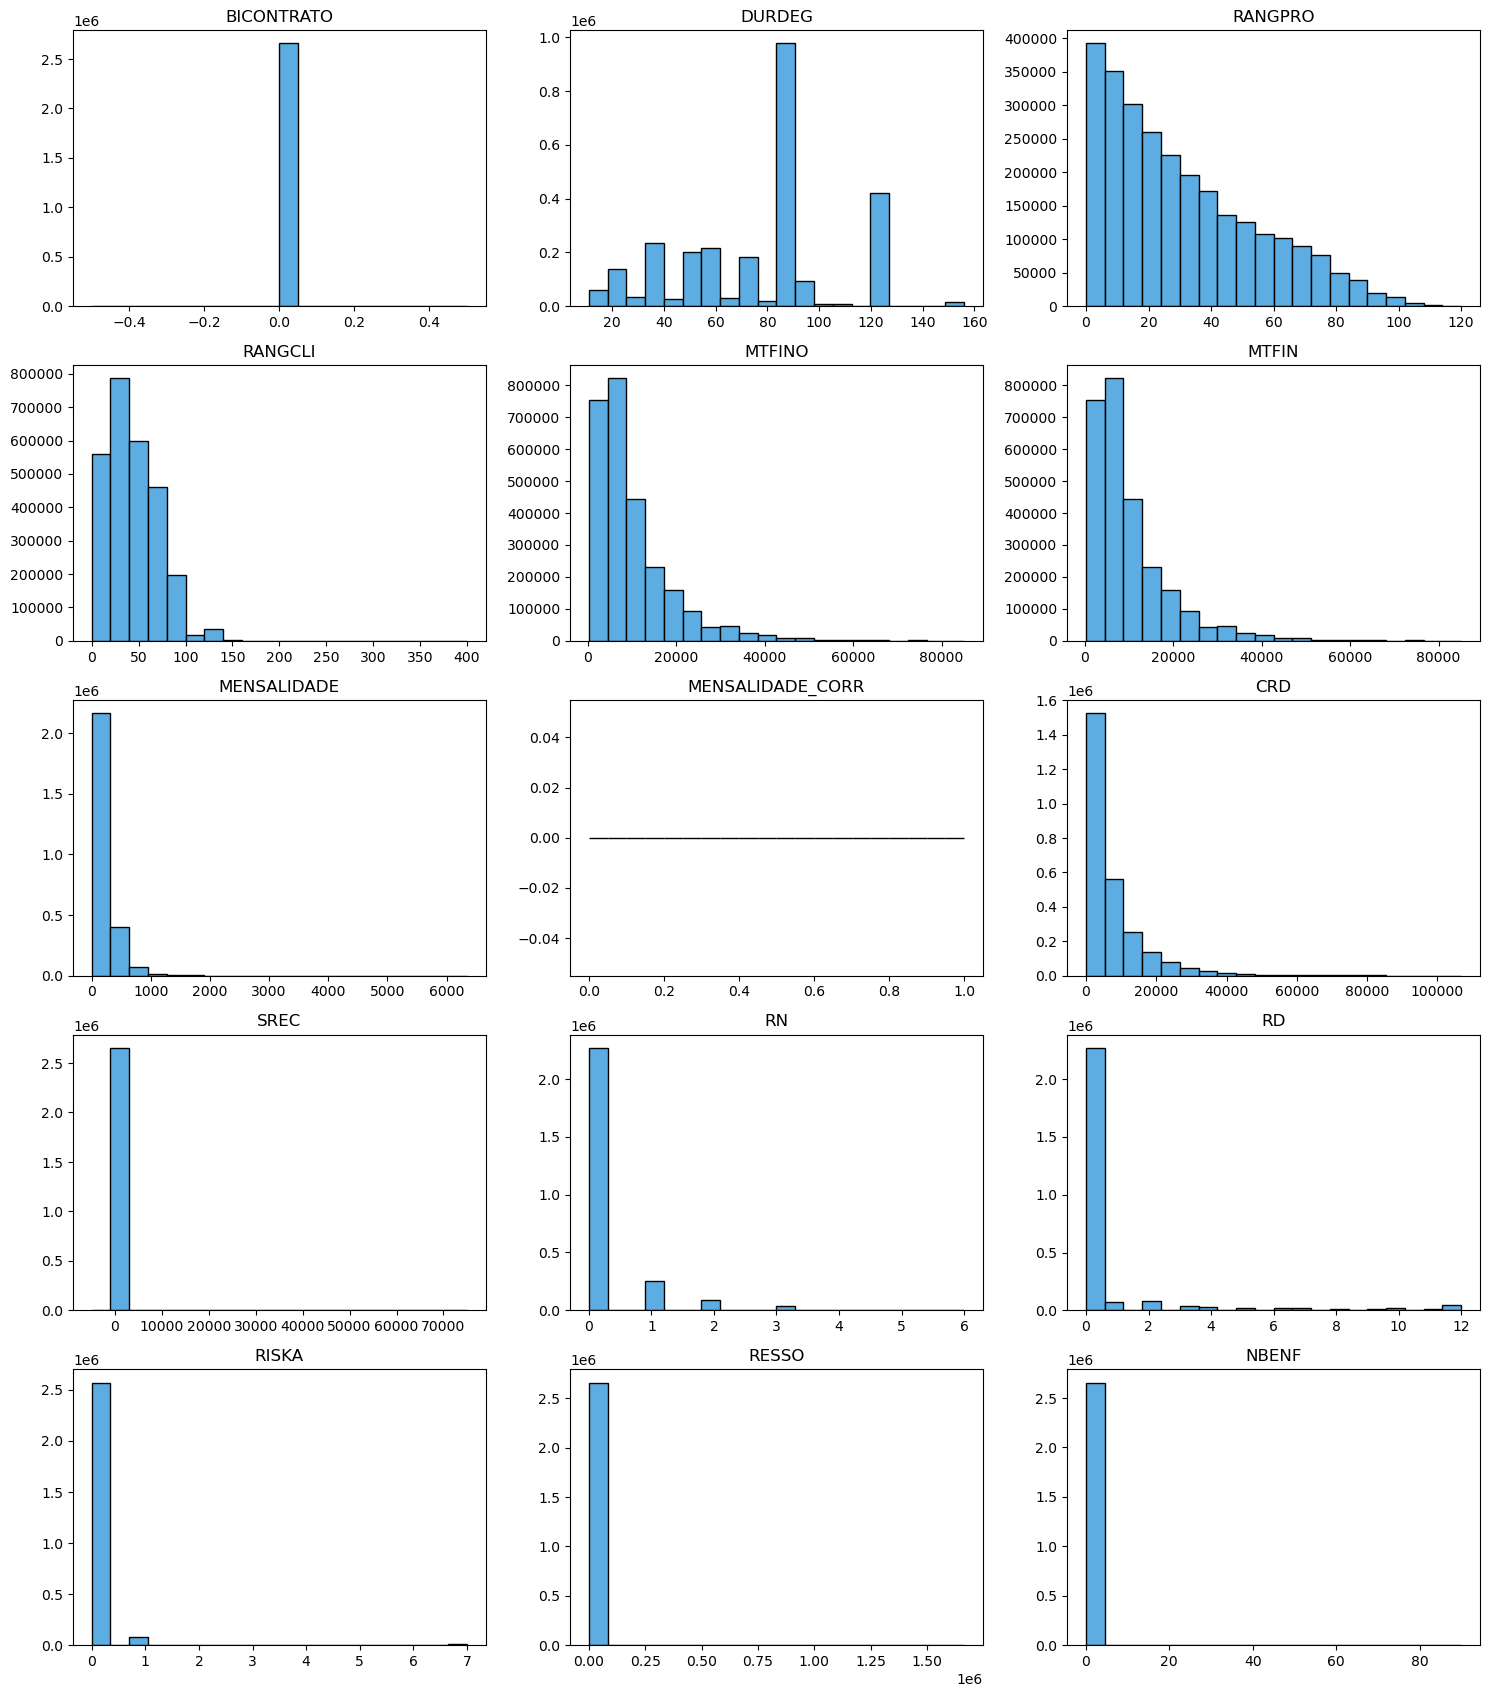

In [73]:
n = len(num_cols)
fig, axes = plt.subplots(nrows = (n // 3) + 1, ncols = 3, figsize = (15, 20))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(BDOSS_num[col].dropna(), bins = 20, color = '#5dade2', edgecolor = 'black')
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    #axes[i].set_ylabel('Frequency')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

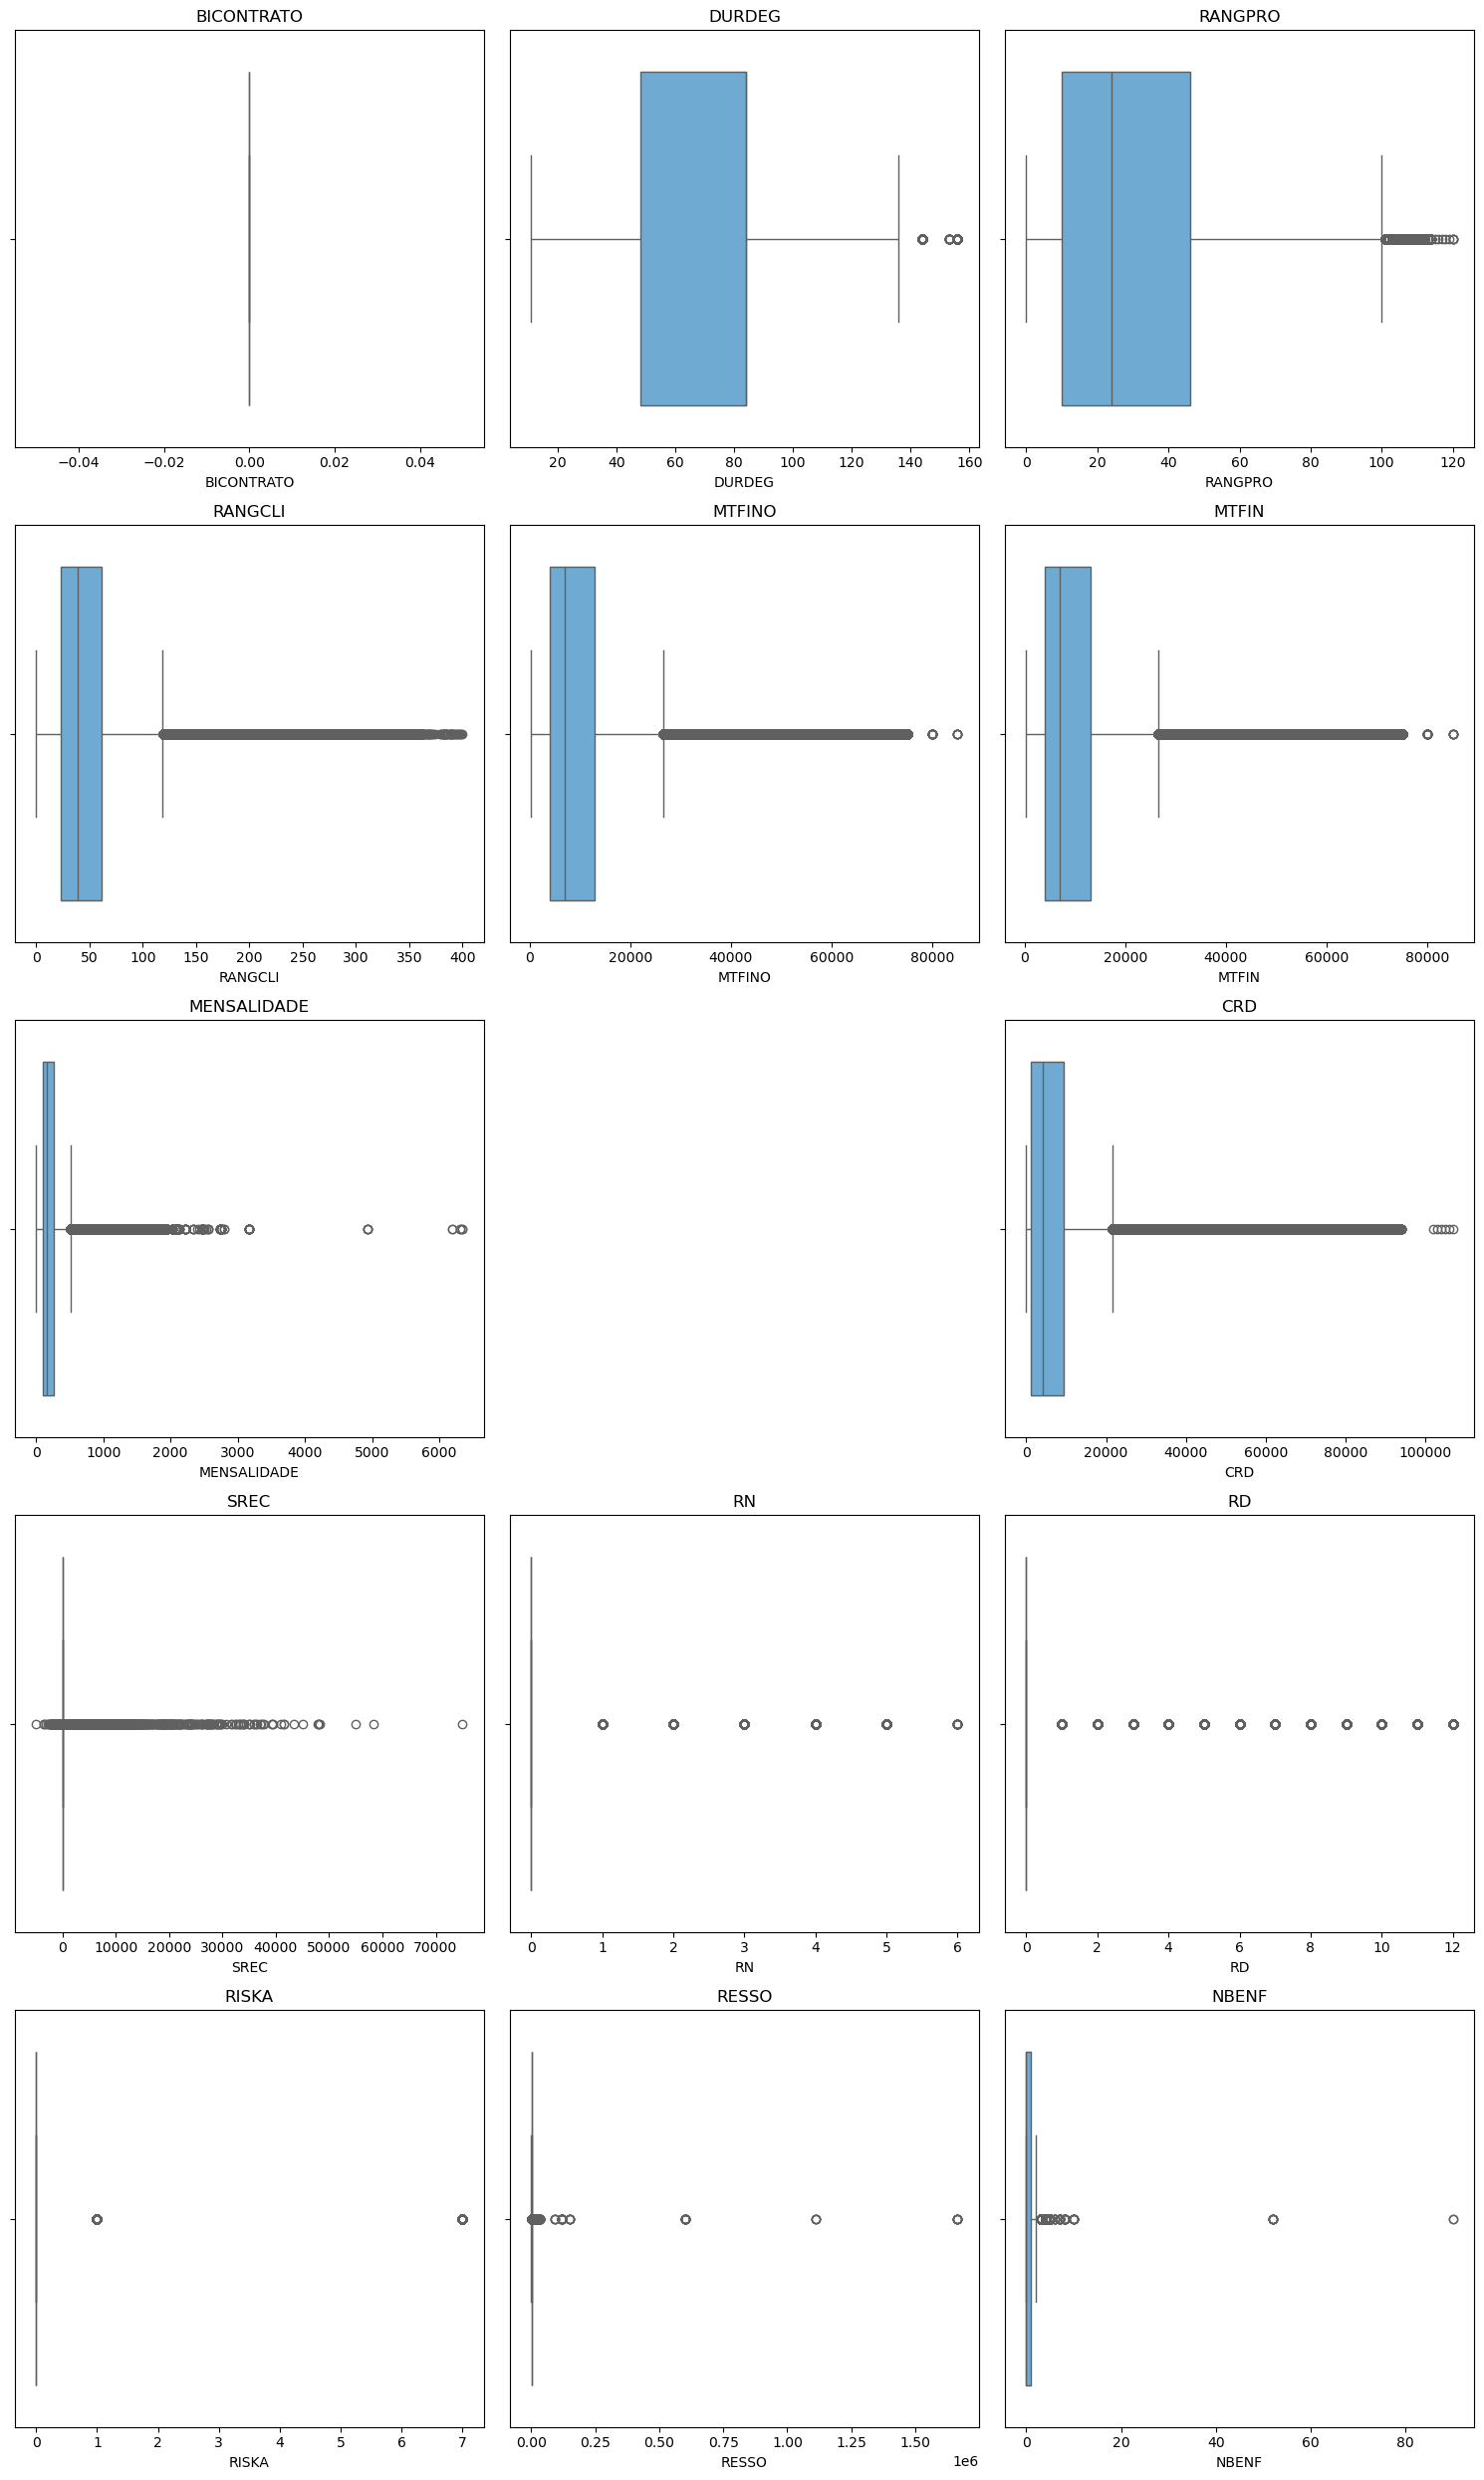

In [ ]:
def plot_multiple_boxplots(data, feats):
    
    n = len(feats)  # número de features
    ncols = 3
    nrows = (n // ncols) + (n % ncols > 0)
    
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 5*nrows))
    axes = axes.flatten()
    
    for i, feat in enumerate(feats):
        # garantir que é numérica
        data[feat] = pd.to_numeric(data[feat], errors="coerce")
        
        # remover NaNs para evitar erro
        clean_data = data[feat].dropna()
        
        if len(clean_data) > 0:
            sns.boxplot(x=clean_data, ax=axes[i], color="#5dade2")
            axes[i].set_title(feat)
        else:
            axes[i].set_visible(False)
    
    # remover eixos extra
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])
    
#    plt.suptitle(title, fontsize=20)
    plt.tight_layout()
    plt.show()

plot_multiple_boxplots(BDOSS, num_cols)

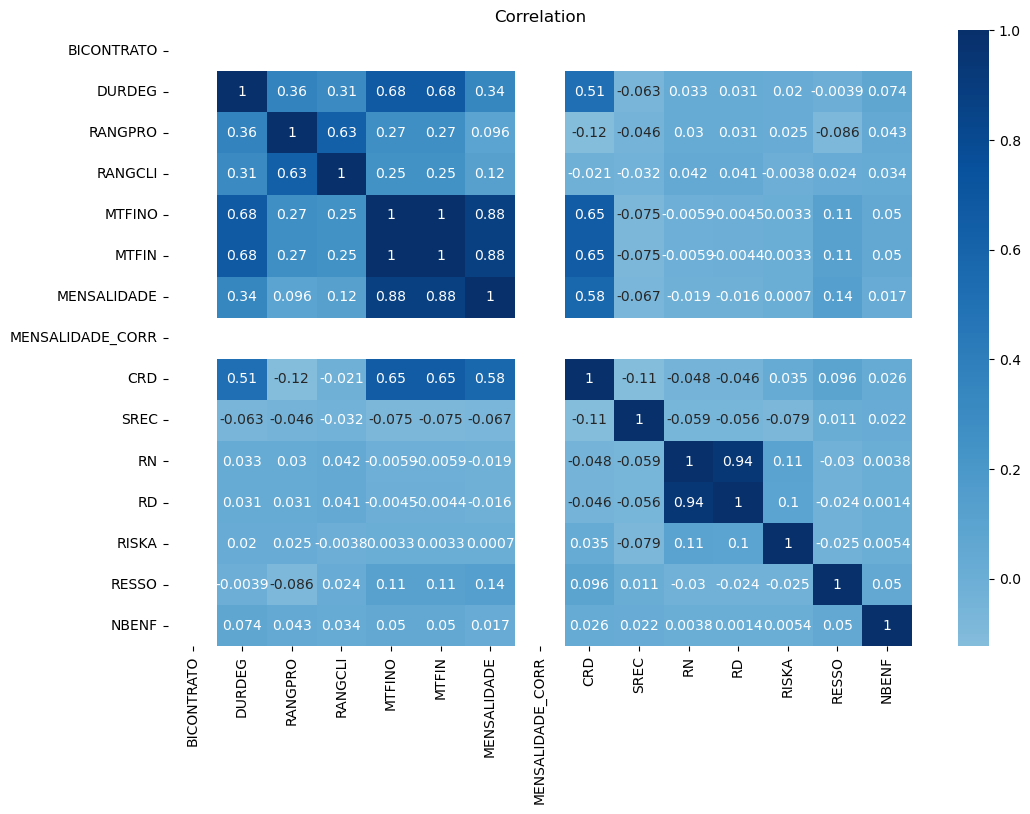

In [ ]:
cor_spearman = BDOSS_num.corr(method ='spearman')

plt.figure(figsize=(12,8))
sns.heatmap(cor_spearman, 
            annot=True, 
            cmap = "Blues", 
            center=0)

plt.title("Correlation")
plt.show()

In [92]:
BDOSS_num.isna().sum()

BICONTRATO                0
DURDEG                    0
RANGPRO                   0
RANGCLI                   1
MTFINO                    0
MTFIN                     0
MENSALIDADE               0
MENSALIDADE_CORR    2658187
CRD                       0
SREC                      0
RN                        0
RD                        0
RISKA                     0
RESSO                     0
NBENF                   736
dtype: int64

In [ ]:
pd.set_option('display.max_columns', None)
BDOSS[BDOSS['RANGCLI'] == 400]


,CONTRIB,DOSSIER,POLE,TYPEPROD,PRODALP,BICONTRATO,POS,OBS_DATE,DCREAT,DATFIN,D1FIN,DPOS,DURDEG,RANGPRO,RANGCLI,MTFINO,MTFIN,MENSALIDADE,MENSALIDADE_CORR,CRD,SREC,ACTIVIDADE_GLOBAL,RN,RD,RISK,RISKA,AGFIN,PAGAMENTO,RESSO,CSP,DCSP,NATIO,PTT,NBENF,MODCONTACTO
2531820,f51344fd4cb7a2d8c74abbfe3dc7e578609caa6b2f09dc...,1dea13fea8125c00e4cc94c800adc3dd224927f17c64ab...,P,CL,EPF,0.0,ENC,2025-10-31,2023-04-24,2023-05-02,2023-05-02,2023-05-02,72.0,30.0,400.0,5500.0,5500.0,125.022187,NaN,4344.892,0.0,NaN,0.0,0.0,000000000000000000000000,0.0,117.0,P,1541.042,90.0,NaN,P,4350,0.0,A


In [112]:
BDOSS_num[BDOSS_num['RANGPRO'] == BDOSS_num['RANGCLI']]

,BICONTRATO,DURDEG,RANGPRO,RANGCLI,MTFINO,MTFIN,MENSALIDADE,MENSALIDADE_CORR,CRD,SREC,RN,RD,RISKA,RESSO,NBENF
0,0.0,120.0,69.0,69.0,20000.0,20000.0,347.447280,NaN,13208.455,0.000,0.0,0.0,0.0,1113.258,1.0
1,0.0,72.0,34.0,34.0,2500.0,2500.0,56.017772,NaN,0.000,0.000,1.0,1.0,0.0,838.186,0.0
2,0.0,84.0,52.0,52.0,5000.0,5000.0,100.073575,NaN,2665.191,0.000,0.0,0.0,0.0,1314.144,2.0
4,0.0,84.0,32.0,32.0,20500.0,20500.0,463.755537,NaN,17844.618,-463.756,2.0,4.0,0.0,1113.258,0.0
6,0.0,72.0,55.0,55.0,5000.0,5000.0,102.689443,NaN,1652.349,0.000,0.0,0.0,0.0,1788.652,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2658181,0.0,36.0,10.0,10.0,5000.0,5000.0,197.885563,NaN,4420.624,0.000,0.0,0.0,0.0,1593.487,0.0
2658182,0.0,120.0,59.0,59.0,12500.0,12500.0,216.051740,NaN,9474.858,0.000,0.0,0.0,0.0,957.059,0.0
2658183,0.0,84.0,83.0,83.0,7430.0,7430.0,157.667572,NaN,137.403,-157.668,1.0,2.0,0.0,977.381,1.0
2658185,0.0,36.0,6.0,6.0,2000.0,2000.0,81.856368,NaN,1994.881,13.462,0.0,0.0,0.0,0.000,2.0


In [68]:
BDOSS_cat

,POLE,TYPEPROD,PRODALP,POS,ACTIVIDADE_GLOBAL,RISK,AGFIN,PAGAMENTO,CSP,NATIO,PTT,MODCONTACTO
0,P,CL,EP,ENC,NaN,000000000000000000000000,120.0,P,80.0,P,2845,A
1,P,CL,EP,SAN,NaN,000000000000210210000110,120.0,N,91.0,P,2855,A
2,P,CL,EP,ENC,NaN,000000000000000000000000,118.0,P,80.0,P,2635,W
3,P,CL,EPF,ENC,NaN,000000000000000000000000,117.0,P,80.0,P,5090,A
4,N,CL,EXT,ENC,NaN,000000000000000002112122,119.0,P,80.0,P,2835,A
...,...,...,...,...,...,...,...,...,...,...,...,...
2658182,P,CL,EP,ENC,NaN,000000000000000000000000,120.0,P,60.0,P,2840,W
2658183,P,CL,EPF,ENC,NaN,000000000000002001111112,118.0,P,31.0,P,4820,W
2658184,P,CL,EP,ENC,NaN,000000000000000000000000,118.0,P,55.0,P,2745,W
2658185,P,CL,EP,ENC,NaN,000000000000000000000011,120.0,P,80.0,P,4485,W


--------

criar uma dataframe separada para cada filtro (SAN e SOL)

In [37]:
SAN = BDOSS[BDOSS['POS'] == 'SAN']
SOL = BDOSS[BDOSS['POS'] == 'SOL']

In [38]:
SAN.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
CONTRIB,275931,40603,e606ca68bd430a98809c05782a0c66b99c5ece7693a578...,72,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DOSSIER,275931,48798,14633cd93da6fc7593eea867c0fdeacd97579c0b67ff4e...,23,NaN,NaN,NaN,NaN,NaN,NaN,NaN
POLE,275931,2,P,268665,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TYPEPROD,275931,1,CL,275931,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PRODALP,275931,4,EP,188477,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BICONTRATO,275931.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
POS,275931,1,SAN,275931,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OBS_DATE,275931,NaN,NaN,NaN,2024-12-24 18:20:49.903780352,2024-01-31 00:00:00,2024-06-30 00:00:00,2024-11-30 00:00:00,2025-06-30 00:00:00,2025-11-30 00:00:00,NaN
DCREAT,275931,NaN,NaN,NaN,2022-01-23 05:57:15.689357312,2011-01-06 00:00:00,2020-06-30 00:00:00,2022-08-08 00:00:00,2023-11-12 00:00:00,2025-11-21 00:00:00,NaN
DATFIN,275931,NaN,NaN,NaN,2022-01-31 18:21:30.296487680,2011-01-18 00:00:00,2020-07-09 00:00:00,2022-08-18 00:00:00,2023-11-17 00:00:00,2025-11-21 00:00:00,NaN


In [39]:
SAN.info()

<class 'pandas.core.frame.DataFrame'>
Index: 275931 entries, 1 to 2658180
Data columns (total 35 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   CONTRIB            275931 non-null  object        
 1   DOSSIER            275931 non-null  object        
 2   POLE               275931 non-null  object        
 3   TYPEPROD           275931 non-null  object        
 4   PRODALP            275931 non-null  object        
 5   BICONTRATO         275931 non-null  float64       
 6   POS                275931 non-null  object        
 7   OBS_DATE           275931 non-null  datetime64[ns]
 8   DCREAT             275931 non-null  datetime64[ns]
 9   DATFIN             275931 non-null  datetime64[ns]
 10  D1FIN              275931 non-null  datetime64[ns]
 11  DPOS               275931 non-null  datetime64[ns]
 12  DURDEG             275931 non-null  float64       
 13  RANGPRO            275931 non-null  float64     